<a href="https://colab.research.google.com/github/unatardedemartes-a11y/ClassFiles/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo_275334.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Livia Daniela Padilla Barragan
- **Matrícula:** 275334

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [2]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media = round(np.mean(df.price),2)
print("Media: ",media)
mediana = round(np.median(df.price),2)
print("Mediana: ",mediana)
valores, conteos = np.unique(df.price, return_counts=True)
moda = valores[np.argmax(conteos)]
print("Moda: ",moda)

Media:  152.72
Mediana:  106.0
Moda:  100


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_

De que existen outliers y la diferencia entre la media y la mediana lo comprueba, ya que la mediana no se ve afectada por ellos

---
## Actividad 2 — Dispersión (20 pts)

In [3]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
min = df.price.min()
max = df.price.max()
print("Min :",min)
print("Max :",max)
rango = max -min
print("Rango: ",rango)
varianza = round(df.price.var(),2)
print("Varianza: ",varianza)
destandar = round(df.price.std(),2)
print("Desviacion estandar: ",destandar)
q1 = np.percentile(df.price, 25)
q2 = np.percentile(df.price, 50)
q3 = np.percentile(df.price, 75)
print("IQR 1: ",q1)
print("IQR 2: ",q2)
print("IQR 3: ",q3)

Min : 0
Max : 10000
Rango:  10000
Varianza:  57674.03
Desviacion estandar:  240.15
IQR 1:  69.0
IQR 2:  106.0
IQR 3:  175.0


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_

 El valor maximo está muy lejos de los valores dentro del 75% de los datos, por lo que IQR es el más representativo de la dispersión típica de los precios

---
## Actividad 3 — Forma (20 pts)

In [4]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
simetria = round(df.price.skew(),2)
curtosis = round(df.price.kurt(),2)
print("Simetria: ",simetria)
print("Curtosis: ",curtosis)


Simetria:  19.12
Curtosis:  585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_

Price tiene muchos más outliers y más extremos que Income lo que tambien nos indica que encontraremos mas datos atipicos

---
## Actividad 4 — Visualización (30 pts)

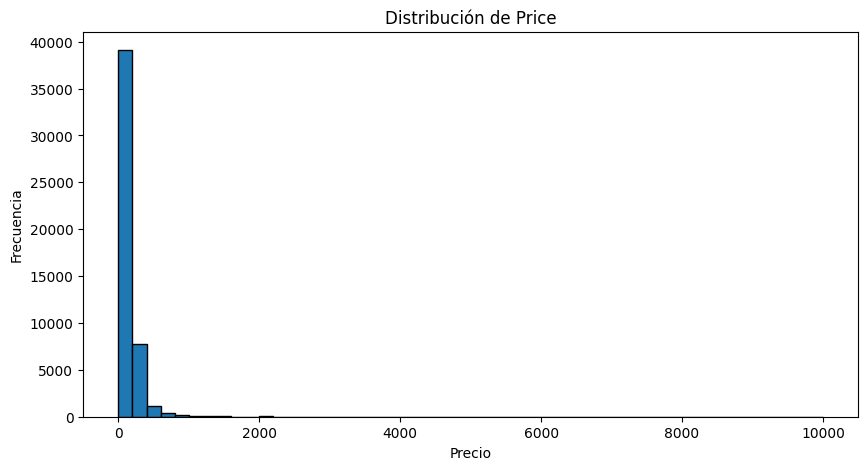

In [5]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.

df['price'].plot(
    kind='hist',
    bins=50,  # entre más sesgada y con más outliers sea la variable, más bins conviene usar, 50 nos permite visuaizar sin tanto ruido
    figsize=(10, 5),
    edgecolor='black'
)
plt.title('Distribución de Price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()


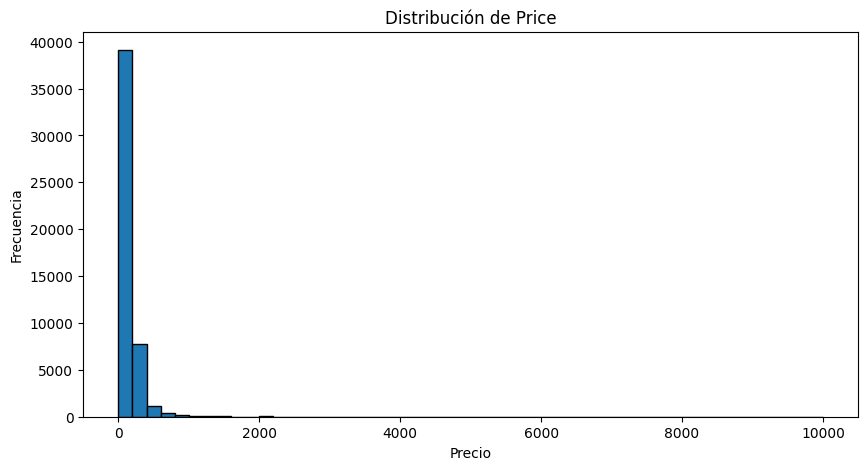

In [6]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50, edgecolor='black')

plt.title('Distribución de Price')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

plt.show()



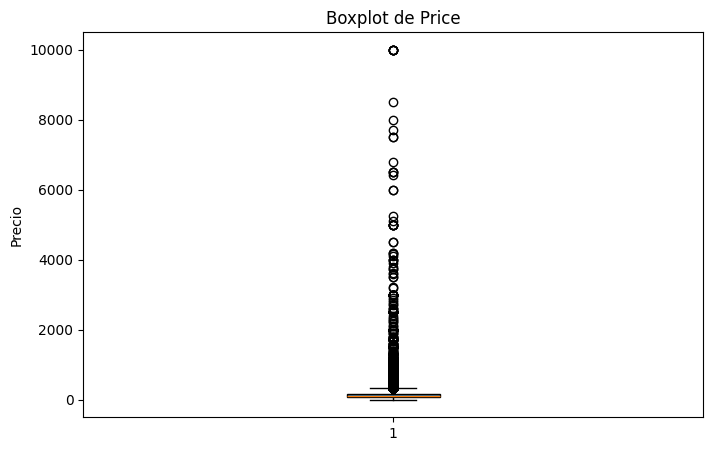

In [7]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).

plt.figure(figsize=(8, 5))
plt.boxplot(df['price'], vert=True, patch_artist=True)

plt.title('Boxplot de Price')
plt.ylabel('Precio')
plt.show()

**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de price. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

*Tu respuesta:*

Ambos gráficos son la confirmacion visual de la actividad 3 y muestran los outliers, pero el boxplot los distingue mucho mejor, porque los marca como puntos individuales y permite ver su cantidad, posición y magnitud

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_

El promedio de 152.72 no es una representacion confiable porque unos pocos productos son muy costosos (hasta 10 000) lo incrementan, mientras que el producto típico cuesta 106 (mediana) y el 75% cuesta menos de 175

---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |